# [DL] Neural Networks

### *Instructions:*
- **과제 명세서를 읽어주시고 코드 작성을 해주시길 바랍니다**</span> 
- **명시된 step을 따라가며 전체적인 학습 방법을 숙지합니다**</span>
- (**첫 번째 cell 결과로 나온 시간을 기준으로 채점을 하겠습니다**</span>).



In [1]:
import datetime
print("This code is run at " + str(datetime.datetime.now()))

This code is run at 2026-07-27 16:48:36.929932


In [4]:
import sys
print(sys.executable)

/home/hojin/miniconda3/envs/ybigta/bin/python


In [9]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn.datasets
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from mlp import MultiLayerPerceptron
import utils

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Problem

Mutilayer Perceptron(```class MutiLayerPerceptron```)으로 간단한 Binary classification task를 진행해봅시다.

> 1. **Dataset**
>> $\texttt{moon}$ dataset

> 2. **Network architecture**
$$
H_1=XW_1+b_1,\qquad z_1=\mathrm{ReLU}(H_1)
$$

$$
H_2=z_1W_2+b_2,\qquad z_2=\mathrm{LeakyReLU}(H_2)
$$

$$
H_3=z_2W_3+b_3,\qquad z_3=\tanh(H_3+H_1)
$$

$$
H_4=z_3W_4+b_4,\qquad \hat y=\sigma(H_4)
$$
 > $ReLU$ $=\max(0,x)$ 
 
 > $LeakyReLU(H_2)$ $=\max(0.01x,x)$ 

 
 > **$W$** and **$b$** 는 각각 weights와 bias.    
 > **weight 초기화**: Standard normal ($\texttt{np.random.randn}$. 사용)  
 > **bias 초기화(intercept)**: 0     
 > **Input size**: 2  
 > **The first hidden layer size**: 10  
 > **The second hidden layer size**: 10  
 > **Output size**: 1   
 > **Regularization parameter $\lambda$**: 0.001  
 > **Loss function**: Binary cross entropy loss (or equivently log loss).  
 > **Total loss** : 
 > $L_{total} = \sum_{i=1}^N{ (-y^{(i)}\log \hat{y}^{(i)} -(1-y^{(i)})\log(1-\hat{y}^{(i)})) } +  \lambda \|W\|^2 $   
 > **Optimization**: Gradient descent  
 > **Learning rate** = 0.0001  
 > **Number of epochs** = 50000  
 > $y$는 정답, $\hat{y}$는 예측값이고 0부터 1사이에 존재한다.  

### STEP 1. 데이터 준비

비교 실험을 위해 train/validation set을 분리합니다.

STEP 1: Load data


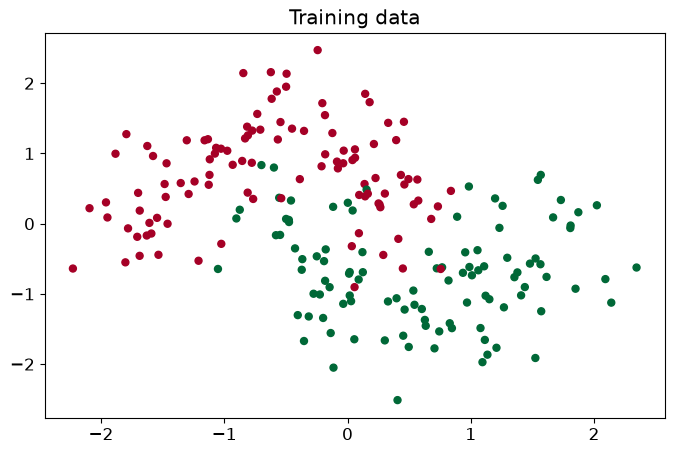

train: (210, 2) validation: (90, 2)


In [10]:
print("STEP 1: Load data")

# Load data
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# Visualize data
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=25, cmap=plt.cm.RdYlGn)
plt.title("Training data")
plt.show()

print("train:", X_train.shape, "validation:", X_val.shape)

## STEP 2. 기본 모델 학습

`mlp.py`의 TODO를 모두 구현한 뒤 아래 셀을 실행하세요.

STEP 2: Train the model
[bgd] epoch=100, train_loss=86.4001, train_acc=0.810
[bgd] epoch=200, train_loss=75.9894, train_acc=0.871
[bgd] epoch=300, train_loss=69.5096, train_acc=0.895
[bgd] epoch=400, train_loss=64.4193, train_acc=0.914
[bgd] epoch=500, train_loss=58.7299, train_acc=0.910
[bgd] epoch=600, train_loss=53.0578, train_acc=0.924
[bgd] epoch=700, train_loss=49.0516, train_acc=0.929
[bgd] epoch=800, train_loss=46.2263, train_acc=0.933
[bgd] epoch=900, train_loss=43.9536, train_acc=0.938
[bgd] epoch=1000, train_loss=41.9957, train_acc=0.938
[bgd] epoch=1100, train_loss=40.2426, train_acc=0.943
[bgd] epoch=1200, train_loss=38.6305, train_acc=0.948
[bgd] epoch=1300, train_loss=37.1382, train_acc=0.952
[bgd] epoch=1400, train_loss=35.8192, train_acc=0.952
[bgd] epoch=1500, train_loss=34.6701, train_acc=0.957
[bgd] epoch=1600, train_loss=33.6805, train_acc=0.957
[bgd] epoch=1700, train_loss=32.7792, train_acc=0.957
[bgd] epoch=1800, train_loss=31.9337, train_acc=0.957
[bgd] epoch=1

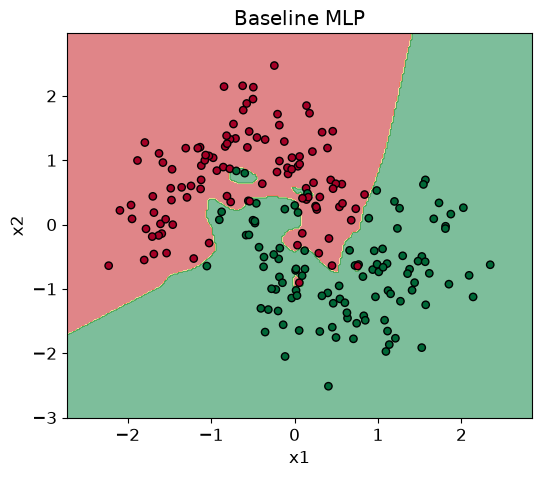

In [11]:
print("STEP 2: Train the model")
# random seed
np.random.seed(0)

# Hyperparameters
nn_input_dim = 2
nn_output_dim = 1
nn_hdim1 = 10
nn_hdim2 = 10
nn_hdim3 = 10
lr = 0.0001 
L2_norm = 0.001
epoch = 50000

model = MultiLayerPerceptron(nn_input_dim, nn_hdim1, nn_hdim2, nn_hdim3, nn_output_dim, init="random")
stats = model.train(X_train, y_train, learning_rate=lr, L2_norm=L2_norm, epoch=epoch, print_loss=True)
utils.plot_decision_boundary(model, X_train, y_train, "Baseline MLP")

## STEP 3. BGD vs SGD vs Mini-batch GD

아래 조건은 세 방법에서 동일하게 고정합니다.

- 동일한 model architecture 및 초기 weight seed
- 동일한 learning rate
- 동일한 epoch 수
- 동일한 train/validation data

In [12]:
print("STEP 3: Compare BGD, SGD, and Mini-batch GD")

# 세 실험에서는 optimizer와 batch_size만 변경합니다.

optimizer_settings = {
    "BGD": {
        "optimizer": "bgd",
        "batch_size": None,
    },
    "SGD": {
        "optimizer": "sgd",
        "batch_size": 1,
    },
    "Mini-batch": {
        "optimizer": "minibatch",
        "batch_size": 32,
    },
}

models = {}
histories = {}

for name, setting in optimizer_settings.items():

    model = MultiLayerPerceptron(
        nn_input_dim,
        nn_hdim1,
        nn_hdim2,
        nn_hdim3,
        nn_output_dim,
        init="random",
    )

    history = model.train(
        X_train,
        y_train,
        X_val,
        y_val,
        learning_rate=lr,
        L2_norm=L2_norm,
        epoch=10000, #step 3에서는 epoch 줄여서 실행
        optimizer=setting["optimizer"],
        batch_size=setting["batch_size"],
        seed=0,
        eval_every=5,
        print_loss=True,
    )

    models[name] = model
    histories[name] = history

utils.result_table(histories)

STEP 3: Compare BGD, SGD, and Mini-batch GD
[bgd] epoch=50, train_loss=100.8804, train_acc=0.800, val_loss=43.3482, val_acc=0.789
[bgd] epoch=100, train_loss=86.4001, train_acc=0.810, val_loss=38.0664, val_acc=0.800
[bgd] epoch=150, train_loss=80.2071, train_acc=0.814, val_loss=36.1744, val_acc=0.800
[bgd] epoch=200, train_loss=75.9894, train_acc=0.871, val_loss=34.9003, val_acc=0.833
[bgd] epoch=250, train_loss=72.4697, train_acc=0.890, val_loss=33.6763, val_acc=0.867
[bgd] epoch=300, train_loss=69.5096, train_acc=0.895, val_loss=32.5396, val_acc=0.867
[bgd] epoch=350, train_loss=66.8955, train_acc=0.895, val_loss=31.6341, val_acc=0.878
[bgd] epoch=400, train_loss=64.4193, train_acc=0.914, val_loss=30.8550, val_acc=0.878
[bgd] epoch=450, train_loss=61.8250, train_acc=0.914, val_loss=30.0760, val_acc=0.878
[bgd] epoch=500, train_loss=58.7299, train_acc=0.910, val_loss=29.2237, val_acc=0.878
[bgd] epoch=550, train_loss=55.7964, train_acc=0.910, val_loss=28.2835, val_acc=0.878
[bgd] epoc

,experiment,updates,elapsed_sec,final_train_loss,final_train_acc,final_val_loss,final_val_acc
0,BGD,10000,3.147928,13.598985,0.971429,29.455395,0.922222
1,SGD,2100000,222.119872,21.512876,0.966667,23.157484,0.900000
2,Mini-batch,70000,10.337755,13.841743,0.971429,29.232358,0.922222


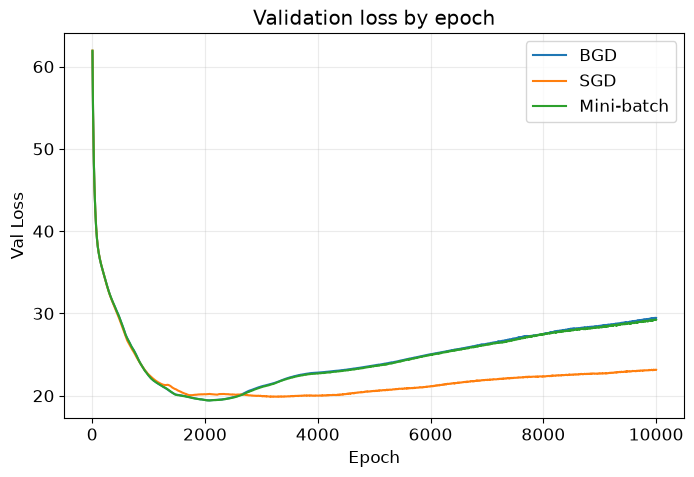

In [13]:
utils.plot_optimizer_histories(
    histories, x_axis="epoch", metric="val_loss",
    title="Validation loss by epoch"
)

## STEP 4. 하이퍼파라미터 탐색

BGD, SGD, Mini-batch GD 중 **하나를 선택**하여 여러 하이퍼파라미터 조합을 자유롭게 실험해봅시다.

변경 가능한 예시:

- learning rate
- epoch
- hidden dimension
- batch size
- L2 regularization strength
- initialization seed

최소 3개 이상의 조합을 시도하고, 아래에 기록하시면 됩니다.

In [ ]:
print("STEP 4: Hyperparameter Tuning")

# TODO: 선택한 optimizer와 시도한 설정으로 아래 내용들을 작성해주세요. 아래는 제가 임의로 작성한 예시이며 자유롭게 작성 하셔도 됩니다.
chosen_optimizer = "minibatch"


# baseline 고정하고 hyperparameter 바꿔가며 결괏값 비교

## hidden: capacity와 과적합 간 트레이드오프
## L2: 정규화가 과적합 막는지 확인
## batch: 배치 크기와 일반화 성능 간 트레이드오프


trial_configs = [
    {
        "name": "trial_baseline",
        "lr": 1e-4,
        "epoch": 3000,
        "hidden": 10,
        "batch_size": 32,
        "l2": 0.0001,
    },
    {
        "name": "trial_hidden_5",
        "lr": 1e-4,
        "epoch": 3000,
        "hidden": 5,
        "batch_size": 32,
        "l2": 0.0001,
    },
    {
        "name": "trial_hidden_30",
        "lr": 1e-4,
        "epoch": 3000,
        "hidden": 30,
        "batch_size": 32,
        "l2": 0.0001,
    },
    {
        "name": "trial_L2_0.1",
        "lr": 1e-4,
        "epoch": 3000,
        "hidden": 10,
        "batch_size": 32,
        "l2": 0.1,
        },
    {
        "name": "trial_batch_128",
        "lr": 1e-4,
        "epoch": 3000,
        "hidden": 10,
        "batch_size": 128,
        "l2": 0.0001,
        },
    {
        "name": "trial_batch_8",
        "lr": 1e-4,
        "epoch": 3000,
        "hidden": 10,
        "batch_size": 8,
        "l2": 0.0001,
        },
    {
            "name": "trial_hidden_lr_1e-3",
            "lr": 1e-3,
            "epoch": 3000,
            "hidden": 5,
            "batch_size": 32,
            "l2": 0.0001,
        },
    {
            "name": "trial_hidden_lr_3e-4",
            "lr": 3e-4,
            "epoch": 3000,
            "hidden": 5,
            "batch_size": 32,
            "l2": 0.0001,
        },
]

trial_models = {}
trial_histories = {}

for cfg in trial_configs:

    model = MultiLayerPerceptron(
        nn_input_dim,
        cfg["hidden"],
        cfg["hidden"],
        cfg["hidden"],
        nn_output_dim,
        init="random",
    )

    history = model.train(
        X_train,
        y_train,
        X_val,
        y_val,
        learning_rate=cfg["lr"],
        L2_norm=cfg["l2"],
        epoch=cfg["epoch"],
        optimizer=chosen_optimizer,
        batch_size=cfg["batch_size"],
        seed=0,
        eval_every=max(1, cfg["epoch"] // 100),
        print_loss=False,
    )

    trial_models[cfg["name"]] = model
    trial_histories[cfg["name"]] = history

utils.result_table(trial_histories)

STEP 4: Hyperparameter Tuning


,experiment,updates,elapsed_sec,final_train_loss,final_train_acc,final_val_loss,final_val_acc
0,trial_baseline,21000,2.745397,25.510145,0.957143,21.068929,0.922222
1,trial_hidden_5,21000,2.605631,32.020717,0.942857,21.088371,0.911111
2,trial_hidden_30,21000,3.481354,12.710341,0.976190,30.855755,0.911111
3,trial_L2_0.1,21000,2.727434,42.261107,0.952381,18.921073,0.900000
4,trial_batch_128,6000,1.072390,25.521469,0.957143,21.116651,0.922222
5,trial_batch_8,81000,9.107914,25.537621,0.957143,21.060745,0.922222
6,trial_hidden_lr_1e-3,21000,2.601011,17.851780,0.957143,29.964452,0.911111
7,trial_hidden_lr_3e-4,21000,2.605524,23.791055,0.952381,19.710071,0.911111


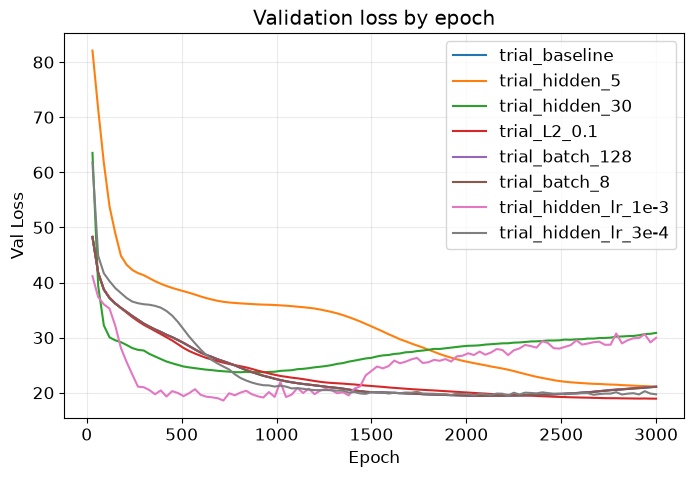

In [19]:
utils.plot_optimizer_histories(
    trial_histories, x_axis="epoch", metric="val_loss",
    title="Validation loss by epoch"
)

In [20]:
# 최적 val_loss 계산

for name, h in trial_histories.items():
    i = int(np.argmin(h["val_loss"]))
    print(f"{name:12s} best_val={h['val_loss'][i]:6.2f} @ep{h['epoch'][i]}")

trial_baseline best_val= 19.42 @ep2070
trial_hidden_5 best_val= 21.09 @ep3000
trial_hidden_30 best_val= 23.72 @ep930
trial_L2_0.1 best_val= 18.92 @ep3000
trial_batch_128 best_val= 19.42 @ep2070
trial_batch_8 best_val= 19.41 @ep2070
trial_hidden_lr_1e-3 best_val= 18.58 @ep720
trial_hidden_lr_3e-4 best_val= 19.48 @ep2220


### STEP 4 시도 내용 및 해석

본인이 시도한 하이퍼파라미터 튜닝 방법에 대해서 자유롭게 기술해주세요. 

ex: 어떤 하이퍼파라미터를 왜 변경했는지, 해당 변경이 모델의 성능이나 학습 시간에 어떤 영향을 미쳤는지 등

(시도한 방법의 성능이 반드시 좋아야 하는 것은 아닙니다. 다양한 하이퍼파라미터를 직접 변경하며 결과를 비교·분석하는 것이 목표이며, 최종 성능 자체는 채점에 반영되지 않습니다.)

> **시도 내용 및 결과 해석:**  

- STEP 3에서 옵티마이저를 BGD, 미니배치, SGD로 설정하여 학습 진행하였음
    - Val loss 곡선 상으로, BGD와 미니배치가 완전히 일치
        - `compute_loss`가 배치 평균이 아닌 합(`np.sum`)으로 정의되어 gradient 크기가 배치 크기에 비례
        - 배치를 키우면 업데이트 횟수가 줄지만 스텝 크기가 그만큼 커짐 -> 에포크당 총 파라미터 이동량 보존
    - SGD는 최종 val loss가 가장 낮았으나, 최저값 자체는 BGD가 더 낮음 (19.44 vs 19.89)
        - SGD의 강점은 더 낮은 지점 도달이 아니라, 최저점 이후 상승이 완만한 것
        - 배치 1개 기준 gradient noise가 커서 좁은 최소점에 안착하지 못함 -> implicit regularization
    - SGD는 에포크당 210회 업데이트로 실행 시간이 약 66배 -> 다중 조합 탐색에 비효율적
    - 세 옵티마이저 모두 2000~3300 구간에서 최저 val loss 도달 후 상승 -> 에포크 10000은 과함
    - 미니배치를 baseline으로 조합 탐색 실행

- Baseline: 미니배치 기반, 학습률 1e-4, 3000 에포크, 은닉층 차원 10, 배치크기 32, L2규제 0.0001 
    - 은닉층 차원 조정: capacity와 과적합 간의 트레이드오프
    - L2 규제값 조정: 과적합 억제와 표현력 제약 간의 트레이드오프
    - 배치크기 조정: 학습 속도와 일반화 성능 간의 트레이드오프
    - 학습률 조정: 수렴 속도와 안정성 간의 트레이드오프

- 은닉층 차원 (5 / 10 / 30): 세 축 중 유일하게 뚜렷한 효과 확인
    - hidden 30: 최저 val 23.72를 930 에포크에서 기록 후 30.86까지 상승
        - 최종 train loss 12.71 vs val loss 30.86 -> 격차 18이 과적합의 직접 증거
    - hidden 5: 3000 에포크에서 최저 val 21.09, 곡선이 여전히 하강 중
        - 표현력 부족이 아니라 수렴이 느린 것으로 판단
    - capacity가 커질수록 과적합 시점이 빨라지고 정도가 심해짐

- 배치크기 (8 / 32 / 128): 일반화 성능에는 영향 없음, 실행 시간만 좌우
    - 최저 val loss 19.41 / 19.42 / 19.42로 사실상 동일, 도달 에포크도 전부 2070
    - 실행 시간 9.11초 / 2.74초 / 1.07초 -> 약 8.5배 차이
    - 원인은 STEP 3과 동일 (합 형태 loss로 인한 실효 스텝 보존)
    - 통상 알려진 "큰 배치 -> 일반화 저하"는 loss가 평균일 때 성립하는 현상
    - 배치 크기가 실효 학습률과 얽혀 상쇄되므로, 실제 스텝을 바꾸려면 학습률을 조정해야 함

- L2 규제 (0.0001 / 0.1): 최저 val loss 18.92로 baseline(19.42) 대비 소폭 개선
    - 단, 최저점이 3000 에포크로 아직 하강 중 -> 충분한 학습이 이루어지지 않음
    - 최종 train loss 42.26은 다른 설정과 비교 불가
        - `train_loss`는 정규화 페널티(0.1 x sum(W^2))가 포함된 값
        - `val_loss`는 `L2_norm=0.0`으로 계산되므로 순수 BCE -> 비교는 val 기준으로 수행
    - 개선폭 0.5는 아래 서술한 seed 노이즈 범위 내로, 유의미한 효과로 단정하기 어려움

- 학습률 (hidden 5 기준, 1e-4 / 3e-4 / 1e-3): hidden 5의 수렴 지연 원인 규명 목적으로 추가 실험
    - lr 3e-4: 최저 val 19.48을 2220 에포크에서 기록
    - lr 1e-3: 최저 val 18.58을 720 에포크에서 기록 -> 8개 조합 중 최고 성능

    - hidden 5가 표현력 부족이었다면 학습률 조정으로 개선되지 않았을 것
        - 학습률 10배 상향만으로 3000 에포크 내 최저점 도달 및 전체 최고값 기록
        - hidden 5의 문제는 capacity가 아닌 수렴 속도였음이 확인됨
        
    - 학습률과 최저점 도달 에포크는 반비례 관계
        - hidden 5: 3e-4 x 2220 = 0.67, 1e-3 x 720 = 0.72
        - hidden 10: 1e-4 x 2070 = 0.21, 3e-4 x 750 = 0.23, 1e-3 x 250 = 0.25
        - 동일 architecture 내에서 (학습률 x 도달 에포크)가 상수에 가까움 -> 총 이동거리가 보존됨
        - 상수값이 architecture별로 다른 것은 파라미터 수에 따라 gradient 크기가 달라지기 때문
    - lr 1e-3의 val loss 곡선은 지그재그 형태 -> 스텝이 커서 미니배치 노이즈가 그대로 드러남
    - 결론적으로 "작은 모델 + 큰 학습률"이 본 문제에서 가장 효율적인 조합

- 결과 해석의 한계
    - 초기화 seed를 0~4로 변경하여 동일 설정 5회 반복 시 val loss 21.13 ~ 27.07 (표준편차 2.36)
        - seed 노이즈가 L2 조정 효과(0.5)보다 큼 -> 단일 실행 결과로 우열 판단 불가
        - 은닉층 차원 30의 악화(11.4 차이)만 노이즈를 명확히 초과하는 효과
    - validation 데이터가 90건에 불과
        - val_acc 0.900 ~ 0.922는 81/90 ~ 83/90으로 1~2건 차이 -> 정확도 기준 비교는 무의미
    - 최저점 도달 에포크가 설정에 따라 720 ~ 3000 이상으로 상이
        - 최종 val loss만으로 우열을 판단할 수 없으므로 최저값과 도달 시점을 함께 기록